 # Decion based models. From decision Tree to Random Forest

### Load the California housing Dataset and Prepare the Data
- Load the California housing dataset from sklearn (`sklearn.datasets.fetch_california_housing()`).
- Separate the features and the target variable, which is 'medv' in this case.
- Analyse the dataset and process different necessary transformations of the data.
- Split the dataset

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.datasets import load_diabetes

# Offline, deterministic dataset (no downloads)
diab = load_diabetes(as_frame=True)
df = diab.frame.copy()
target_name = 'target'
print('Loaded dataset: Diabetes (sklearn built-in)')

X = df.drop(columns=[target_name])
y = df[target_name]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)
print('Train:', X_train.shape, 'Test:', X_test.shape)


Loaded dataset: Diabetes (sklearn built-in)
Train: (309, 10) Test: (133, 10)


###  Fit the Regression Tree
- Fit a decision tree to the training data.
- Try to vizualize the behavior of the DT while changing parameters

Baseline DT
Train MSE: 0.0
Test  MSE: 5697.789473684211
Test  R2 : -0.05547696148647652


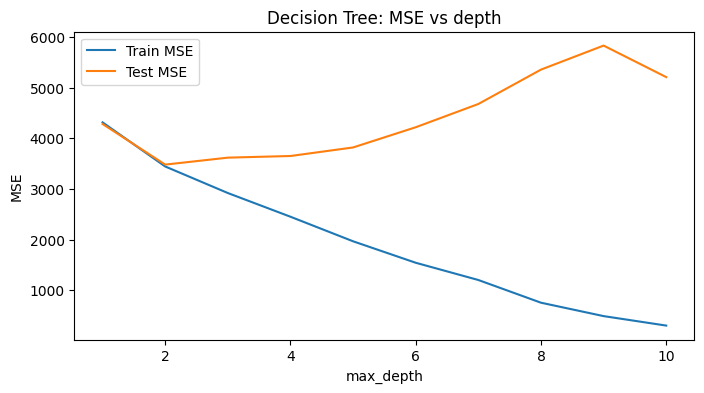

Best depth by test MSE: 2  (MSE= 3479.644254558814 )


In [5]:
# Baseline regression tree
dt_base = DecisionTreeRegressor(random_state=42)
dt_base.fit(X_train, y_train)

pred_train = dt_base.predict(X_train)
pred_test  = dt_base.predict(X_test)

print("Baseline DT")
print("Train MSE:", mean_squared_error(y_train, pred_train))
print("Test  MSE:", mean_squared_error(y_test, pred_test))
print("Test  R2 :", r2_score(y_test, pred_test))

# Explore how max_depth affects bias/variance
depths = list(range(1, 11))
train_mse, test_mse = [], []
for d in depths:
    m = DecisionTreeRegressor(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_mse.append(mean_squared_error(y_train, m.predict(X_train)))
    test_mse.append(mean_squared_error(y_test,  m.predict(X_test)))

plt.figure(figsize=(8,4))
plt.plot(depths, train_mse, label="Train MSE")
plt.plot(depths, test_mse, label="Test MSE")
plt.xlabel("max_depth")
plt.ylabel("MSE")
plt.title("Decision Tree: MSE vs depth")
plt.legend()
plt.show()

best_depth = depths[int(np.argmin(test_mse))]
print("Best depth by test MSE:", best_depth, " (MSE=", min(test_mse), ")")


### Perform Cost Complexity Pruning
- Apply cost complexity pruning to the regression tree using the appropriate library function : `cost_complexity_pruning_path()`
- Determine the optimal pruning parameter `ccp_alpha` through cross-validation

Best ccp_alpha: 436.3442287203411
Best CV MSE: 4775.622534126987


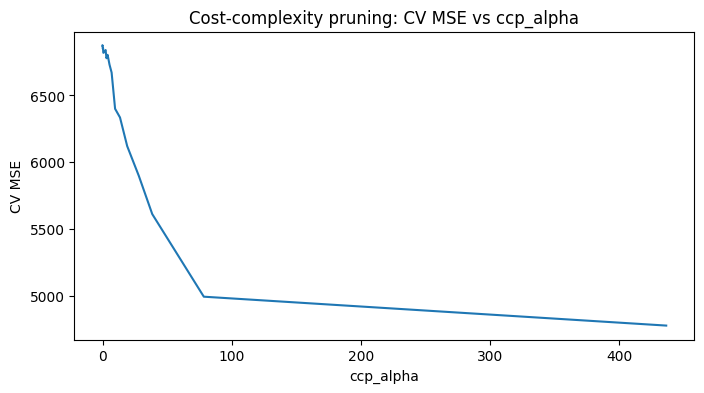

In [6]:
from sklearn.model_selection import GridSearchCV, KFold

# Get pruning path
path = dt_base.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Remove the maximum alpha that prunes everything (often makes a stump)
ccp_alphas = ccp_alphas[:-1]

# To keep runtime low, subsample alphas if there are many
if len(ccp_alphas) > 30:
    idx = np.linspace(0, len(ccp_alphas)-1, 30).astype(int)
    ccp_alphas = ccp_alphas[idx]

# Grid search over ccp_alpha
param_grid = {"ccp_alpha": ccp_alphas}
cv = KFold(n_splits=4, shuffle=True, random_state=42)

dt_for_prune = DecisionTreeRegressor(random_state=42)

gs = GridSearchCV(
    n_jobs=-1,
    estimator=dt_for_prune,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=cv,
    # n_jobs=None
)
gs.fit(X_train, y_train)

print("Best ccp_alpha:", gs.best_params_["ccp_alpha"])
print("Best CV MSE:", -gs.best_score_)

# Plot CV curve (alpha vs CV MSE)
mean_mse = -gs.cv_results_["mean_test_score"]
plt.figure(figsize=(8,4))
plt.plot(ccp_alphas, mean_mse)
plt.xlabel("ccp_alpha")
plt.ylabel("CV MSE")
plt.title("Cost-complexity pruning: CV MSE vs ccp_alpha")
plt.show()

best_dt = gs.best_estimator_


### Analyze the results
- Use the best estimator obtained from cross-validation to make predictions on the test set
- Utilize the `predict()` method of the best estimator to generate predictions for the test data
- Evaluate the Performance of the Model on the Test Set
- Plot the tree to see if its interpretable

Pruned DT performance
Test MSE: 4280.762895394589
Test R2 : 0.20701762770578158


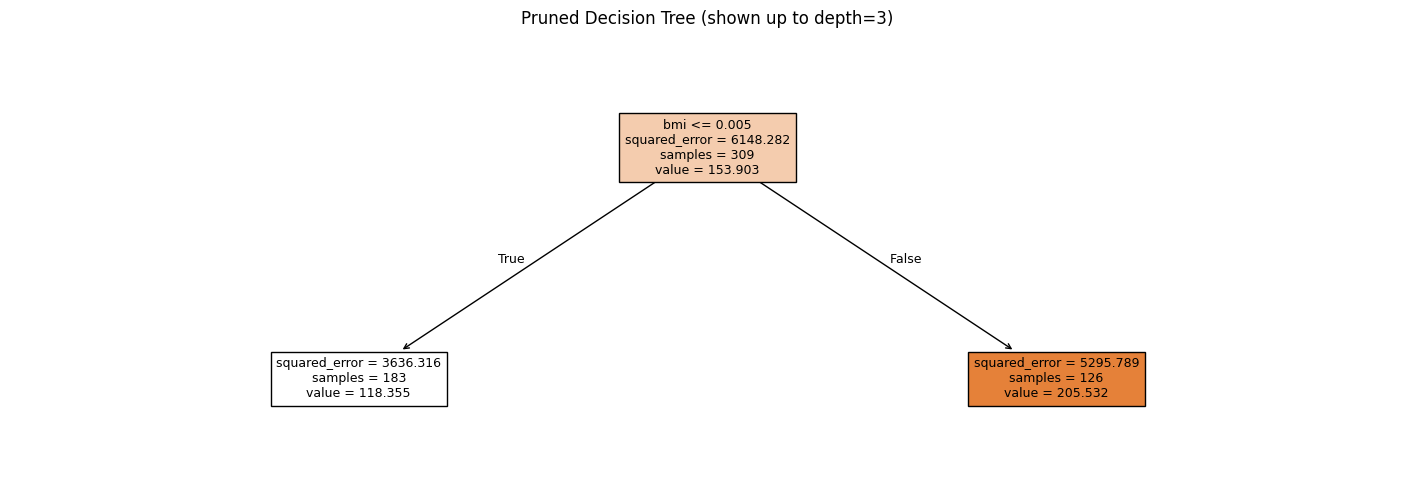

In [7]:
# Evaluate best estimator on test set
y_pred = best_dt.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

print("Pruned DT performance")
print("Test MSE:", test_mse)
print("Test R2 :", test_r2)

# Plot tree (limit depth for readability)
plt.figure(figsize=(18,6))
plot_tree(
    best_dt,
    feature_names=list(X.columns),
    filled=True,
    max_depth=3,
    fontsize=9
)
plt.title("Pruned Decision Tree (shown up to depth=3)")
plt.show()


### Some questions

- When learning the tree, we chose a feature to test at each step by maximizing the expected information gain. Does this approach allow us to generate the optimal decision
tree ? Why or why not ? Hint : When playing chess, do you consider only the immediate improvement of your position when deciding on your next move ?

- Why might a Decision Tree work well on a small dataset but perform poorly on a larger one ?

- How does the depth of the tree impact its performance in terms of overfitting and underfitting ?

- How are categorical features handled during splitting ?
 
- In your opinion, why is feature scaling not required when training a Decision Tree ?

- When splitting a node, what happens if all observations have the same target value ?

- What Decision Trees are often described as "white-box models". What does this mean, and why is it beneficial in certain applications ?

- If your dataset is imbalanced, how might this affect the splits chosen by the Decision Tree ? What adjustments could you make to address this ?

## Experiment Boostrapping

- Write a function that creates bootstrap samples by randomly sampling data points with replacement from the training set
- Train multiple Decision Tree models, each using a different bootstrap sample
- Generate predictions from each model for a fixed test set and store the results
- Compute the mean, standard deviation, and range of predictions for each test point across the models

In [8]:
from collections import defaultdict

rng = np.random.default_rng(42)

def bootstrap_sample(X, y, rng):
    n = len(X)
    idx = rng.integers(0, n, size=n)  # sample with replacement
    return X.iloc[idx], y.iloc[idx], idx

B = 50  # number of bootstrap models
boot_models = []
boot_preds = []

for b in range(B):
    Xb, yb, idx = bootstrap_sample(X_train, y_train, rng)
    m = DecisionTreeRegressor(random_state=42 + b)
    m.fit(Xb, yb)
    boot_models.append(m)
    boot_preds.append(m.predict(X_test))

boot_preds = np.vstack(boot_preds)  # shape (B, n_test)

pred_mean = boot_preds.mean(axis=0)
pred_std  = boot_preds.std(axis=0)
pred_min  = boot_preds.min(axis=0)
pred_max  = boot_preds.max(axis=0)

summary = pd.DataFrame({
    "y_true": y_test.values,
    "pred_mean": pred_mean,
    "pred_std": pred_std,
    "pred_min": pred_min,
    "pred_max": pred_max,
    "pred_range": pred_max - pred_min
})
display(summary.head())
print("Avg std across test points:", summary["pred_std"].mean())


,y_true,pred_mean,pred_std,pred_min,pred_max,pred_range
0,219.0,143.88,56.288414,67.0,259.0,192.0
1,70.0,183.38,64.371699,79.0,293.0,214.0
2,202.0,153.34,51.432523,69.0,283.0,214.0
3,230.0,247.84,45.392228,132.0,317.0,185.0
4,111.0,107.16,51.636561,44.0,262.0,218.0


Avg std across test points: 53.478673403145656


- Create some vizualisation to compare the mean predictions with the true values
- Show the distribution of predictions for a few selected test points

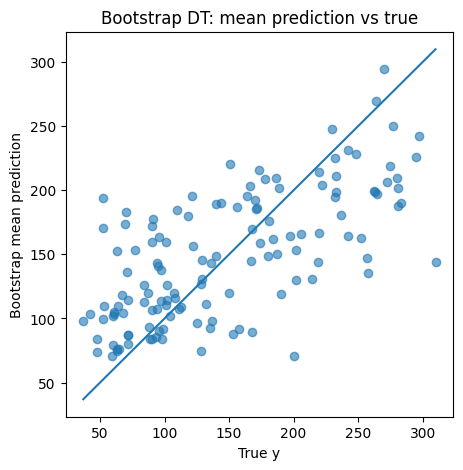

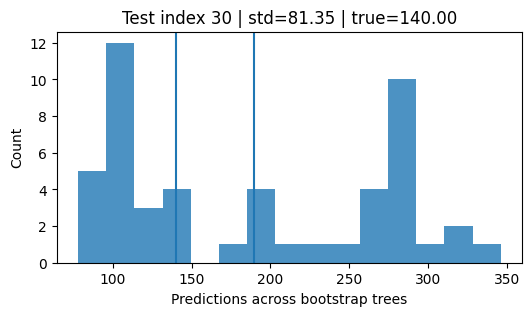

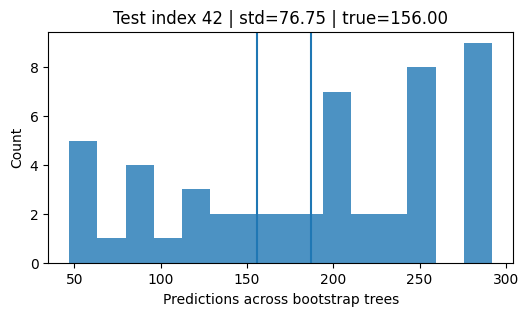

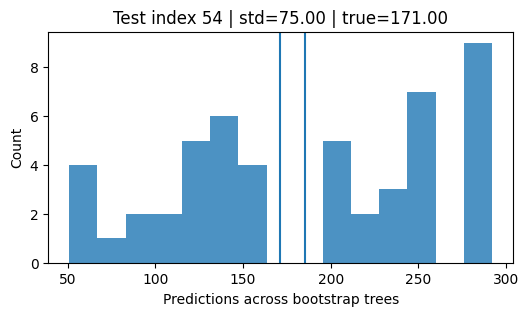

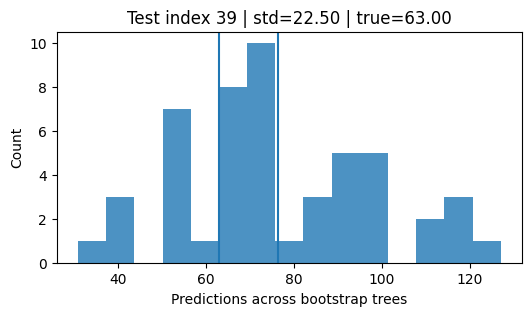

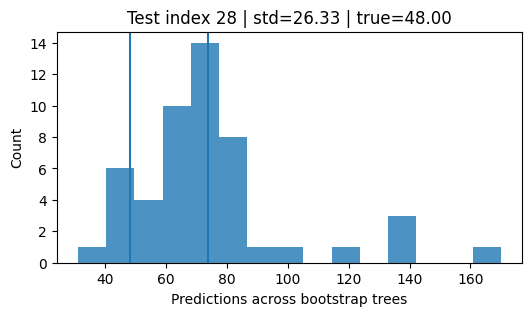

In [9]:
# Mean predictions vs true values
plt.figure(figsize=(5,5))
plt.scatter(summary["y_true"], summary["pred_mean"], alpha=0.6)
m = min(summary["y_true"].min(), summary["pred_mean"].min())
M = max(summary["y_true"].max(), summary["pred_mean"].max())
plt.plot([m, M], [m, M])
plt.xlabel("True y")
plt.ylabel("Bootstrap mean prediction")
plt.title("Bootstrap DT: mean prediction vs true")
plt.show()

# Distribution of predictions for a few selected test points
chosen = summary.sort_values("pred_std", ascending=False).head(3).index.tolist()
chosen += summary.sort_values("pred_std", ascending=True).head(2).index.tolist()
chosen = list(dict.fromkeys(chosen))[:5]

for i in chosen:
    plt.figure(figsize=(6,3))
    plt.hist(boot_preds[:, i], bins=15, alpha=0.8)
    plt.axvline(summary.loc[i, "y_true"])
    plt.axvline(summary.loc[i, "pred_mean"])
    plt.title(f"Test index {i} | std={summary.loc[i,'pred_std']:.2f} | true={summary.loc[i,'y_true']:.2f}")
    plt.xlabel("Predictions across bootstrap trees")
    plt.ylabel("Count")
    plt.show()


- How does the variance of predictions change across test samples ?
- Why do some test points exhibit higher variance ?
- How does this relate to the overfitting tendency of Decision Trees ?
- How might combining predictions help to reduce variance ?

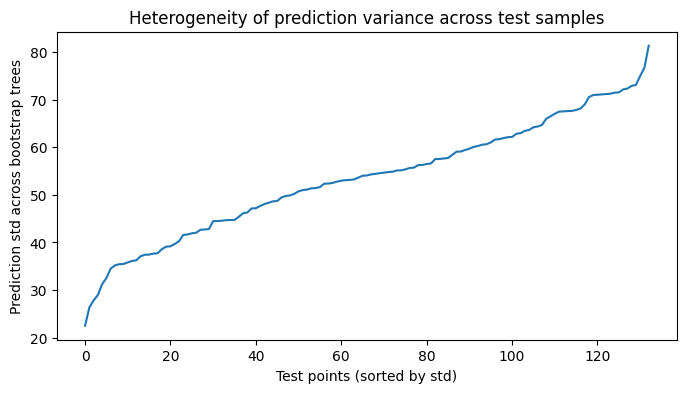

,y_true,pred_mean,pred_std,pred_min,pred_max,pred_range
30,140.0,189.60,81.352320,78.0,346.0,268.0
42,156.0,186.96,76.749192,47.0,292.0,245.0
54,171.0,185.44,74.998976,51.0,292.0,241.0
62,187.0,150.34,73.110494,42.0,293.0,251.0
97,167.0,145.14,72.918862,78.0,346.0,268.0
120,121.0,195.18,72.354043,49.0,302.0,253.0
80,68.0,104.60,72.163148,40.0,302.0,262.0
26,263.0,198.76,71.536721,85.0,341.0,256.0
33,164.0,195.28,71.477560,66.0,311.0,245.0
95,281.0,187.60,71.258964,44.0,346.0,302.0


Interpretation:
- Higher variance often appears for 'hard' regions of the feature space with fewer similar training points,
  or near decision boundaries where small changes in bootstrap sample alter splits.
- Lower variance appears where the relationship is stable and many similar training points exist.


In [10]:
# How variance changes across test samples
plt.figure(figsize=(8,4))
plt.plot(np.sort(summary["pred_std"].values))
plt.xlabel("Test points (sorted by std)")
plt.ylabel("Prediction std across bootstrap trees")
plt.title("Heterogeneity of prediction variance across test samples")
plt.show()

# Investigate which samples have high variance
high_var = summary.sort_values("pred_std", ascending=False).head(10)
display(high_var)

print(
    "Interpretation:\n"
    "- Higher variance often appears for 'hard' regions of the feature space with fewer similar training points,\n"
    "  or near decision boundaries where small changes in bootstrap sample alter splits.\n"
    "- Lower variance appears where the relationship is stable and many similar training points exist."
)


- Try using a different weak learners with the same setup and compare their prediction variance
- Increase or decrease the number of bootstrap samples. How does this affect the results ?

,dt_std,lr_std
count,133.000000,133.000000
mean,53.478673,10.142891
std,12.189832,2.584945
min,22.496613,4.807143
25%,44.688115,8.461473
50%,54.078994,9.503294
75%,62.119575,11.545900
max,81.352320,18.054123


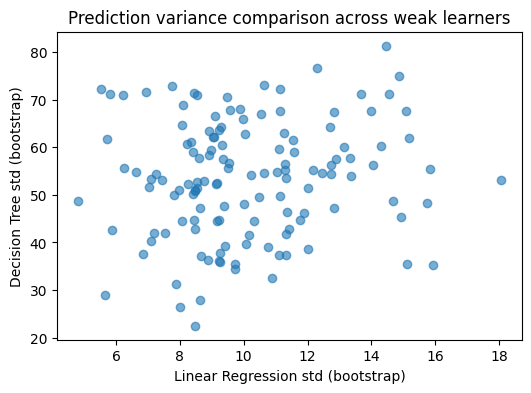

Observation: trees usually show higher variance than linear models because split structure can change a lot
across bootstrap samples; linear regression is more stable (lower variance).


In [11]:
from sklearn.linear_model import LinearRegression

# Compare variance using a different weak learner (Linear Regression) with the same bootstrap sampling
B2 = 50
lin_preds = []
rng2 = np.random.default_rng(123)

for b in range(B2):
    Xb, yb, idx = bootstrap_sample(X_train, y_train, rng2)
    lr = LinearRegression()
    lr.fit(Xb, yb)
    lin_preds.append(lr.predict(X_test))

lin_preds = np.vstack(lin_preds)
lin_std = lin_preds.std(axis=0)

compare = pd.DataFrame({
    "dt_std": pred_std,
    "lr_std": lin_std
})
display(compare.describe())

plt.figure(figsize=(6,4))
plt.scatter(compare["lr_std"], compare["dt_std"], alpha=0.6)
plt.xlabel("Linear Regression std (bootstrap)")
plt.ylabel("Decision Tree std (bootstrap)")
plt.title("Prediction variance comparison across weak learners")
plt.show()

print(
    "Observation: trees usually show higher variance than linear models because split structure can change a lot\n"
    "across bootstrap samples; linear regression is more stable (lower variance)."
)


### Bagging Implementation

- In order to improve the MSE and reduce the variance of the results implement your own Bagging class.

- Recall that Bagging is performed when all predictors (i.e. covariates - features) are used.

In [12]:
from dataclasses import dataclass

@dataclass
class MyBaggingRegressor:
    n_estimators: int = 100
    max_samples: float = 1.0        # fraction of training set per bootstrap sample
    random_state: int = 42
    base_params: dict = None        # parameters for DecisionTreeRegressor

    def fit(self, X, y):
        self.X_ = X.reset_index(drop=True)
        self.y_ = y.reset_index(drop=True)
        self.models_ = []
        self.inbag_indices_ = []    # store bootstrap indices for OOB

        rng = np.random.default_rng(self.random_state)
        n = len(self.X_)
        m = int(np.ceil(self.max_samples * n))

        params = dict(self.base_params or {})
        for k in range(self.n_estimators):
            idx = rng.integers(0, n, size=m)
            Xb = self.X_.iloc[idx]
            yb = self.y_.iloc[idx]
            model = DecisionTreeRegressor(random_state=self.random_state + k, **params)
            model.fit(Xb, yb)
            self.models_.append(model)
            self.inbag_indices_.append(idx)
        return self

    def predict(self, X):
        preds = np.vstack([m.predict(X) for m in self.models_])
        return preds.mean(axis=0)

    def oob_predict(self):
        # OOB prediction for training points using trees that did NOT see that point
        n = len(self.X_)
        preds_sum = np.zeros(n)
        preds_cnt = np.zeros(n)

        for model, idx in zip(self.models_, self.inbag_indices_):
            inbag = np.zeros(n, dtype=bool)
            inbag[idx] = True
            oob_idx = np.where(~inbag)[0]
            if len(oob_idx) == 0:
                continue
            p = model.predict(self.X_.iloc[oob_idx])
            preds_sum[oob_idx] += p
            preds_cnt[oob_idx] += 1

        oob = np.full(n, np.nan)
        mask = preds_cnt > 0
        oob[mask] = preds_sum[mask] / preds_cnt[mask]
        return oob


- Fit your Bagging regressor to the training data. Compare it to `DecisionTree` Sklearn built-in class.

In [13]:
# Fit our Bagging regressor
bag = MyBaggingRegressor(
    n_estimators=120,
    max_samples=1.0,
    random_state=42,
    base_params={"max_depth": None}
)
bag.fit(X_train, y_train)

# Compare on test set
bag_test_pred = bag.predict(X_test)
dt_test_pred  = best_dt.predict(X_test)

print("Decision Tree (pruned) Test MSE:", mean_squared_error(y_test, dt_test_pred))
print("Bagging Test MSE:", mean_squared_error(y_test, bag_test_pred))

# OOB error for Bagging (on training set)
oob = bag.oob_predict()
oob_mask = ~np.isnan(oob)
oob_mse = mean_squared_error(y_train.iloc[oob_mask], oob[oob_mask])
print("Bagging OOB MSE (train):", oob_mse)


Decision Tree (pruned) Test MSE: 4280.762895394589
Bagging Test MSE: 2858.0870123224727
Bagging OOB MSE (train): 3549.6378724034316


- Effect of Increasing Trees in Bagging : 
    - Vizualize the effect of increasing the number of weak learners. 
    - Does increasing the number of trees always help ?

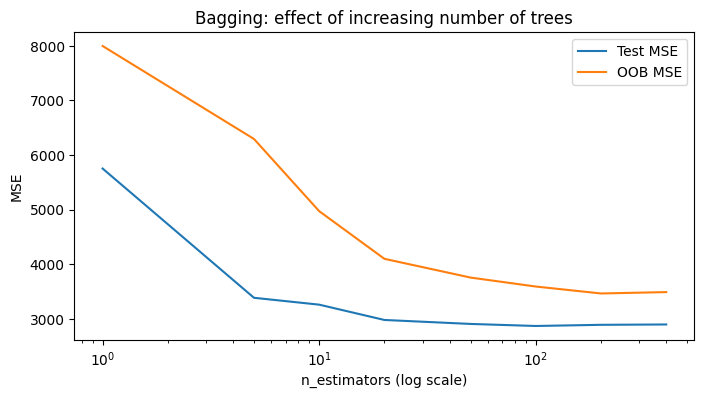

Answer: Increasing trees usually helps (lower variance), but gains diminish; after enough trees
the curve flattens because averaging has already stabilized predictions.


In [14]:
# Effect of number of trees on OOB and test error
tree_counts = [1, 5, 10, 20, 50, 100, 200, 400]
oob_mses = []
test_mses = []

for t in tree_counts:
    b = MyBaggingRegressor(n_estimators=t, max_samples=1.0, random_state=42)
    b.fit(X_train, y_train)
    test_mses.append(mean_squared_error(y_test, b.predict(X_test)))
    oob = b.oob_predict()
    mask = ~np.isnan(oob)
    oob_mses.append(mean_squared_error(y_train.iloc[mask], oob[mask]))

plt.figure(figsize=(8,4))
plt.plot(tree_counts, test_mses, label="Test MSE")
plt.plot(tree_counts, oob_mses, label="OOB MSE")
plt.xscale("log")
plt.xlabel("n_estimators (log scale)")
plt.ylabel("MSE")
plt.title("Bagging: effect of increasing number of trees")
plt.legend()
plt.show()

print(
    "Answer: Increasing trees usually helps (lower variance), but gains diminish; after enough trees\n"
    "the curve flattens because averaging has already stabilized predictions."
)


### Random Forest
Random Forest introduces additional randomness by restricting the number of features that each tree can consider when splitting a node.

Usually, $\sqrt{p}$ features for classification and $p/3$ for regression, where $p$ is the total number of features.

This restriction decorrelates the trees, reducing the chance of overfitting even further.

- Modify your class to chose the maximum number of features to consider when searching for the best split. 

In [15]:
@dataclass
class MyRandomForestRegressor(MyBaggingRegressor):
    max_features: object = "sqrt"  # int, float, "sqrt", "log2", or None

    def fit(self, X, y):
        self.X_ = X.reset_index(drop=True)
        self.y_ = y.reset_index(drop=True)
        self.models_ = []
        self.inbag_indices_ = []

        rng = np.random.default_rng(self.random_state)
        n = len(self.X_)
        m = int(np.ceil(self.max_samples * n))

        params = dict(self.base_params or {})
        params["max_features"] = self.max_features

        for k in range(self.n_estimators):
            idx = rng.integers(0, n, size=m)
            Xb = self.X_.iloc[idx]
            yb = self.y_.iloc[idx]
            model = DecisionTreeRegressor(random_state=self.random_state + k, **params)
            model.fit(Xb, yb)
            self.models_.append(model)
            self.inbag_indices_.append(idx)
        return self


- Create a plot displaying the test, train and OOB error resulting from random forests for a more comprehensive range of values for max_features and n_estimators
- Describe the results obtained

,max_features,n_estimators,train_mse,test_mse,oob_mse
0,None,10,674.255955,3258.589023,4970.378062
1,None,30,540.202848,2939.142598,3875.343997
2,None,60,520.271890,2889.144317,3674.426236
3,None,120,492.947300,2858.087012,3549.637872
4,None,240,480.476574,2902.219674,3476.719101


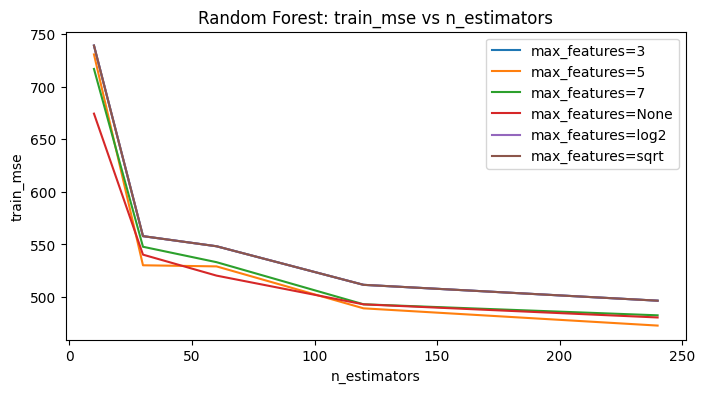

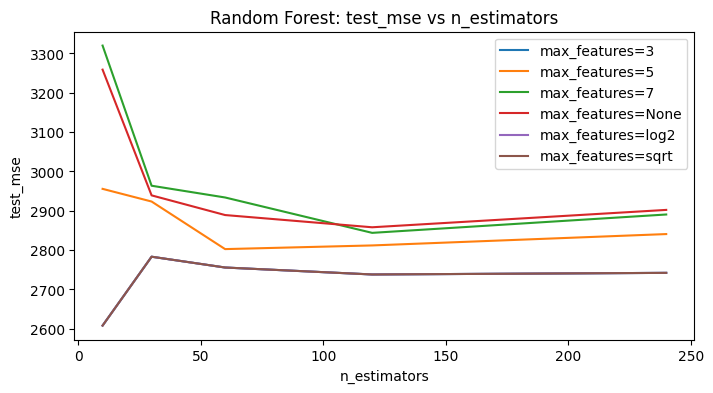

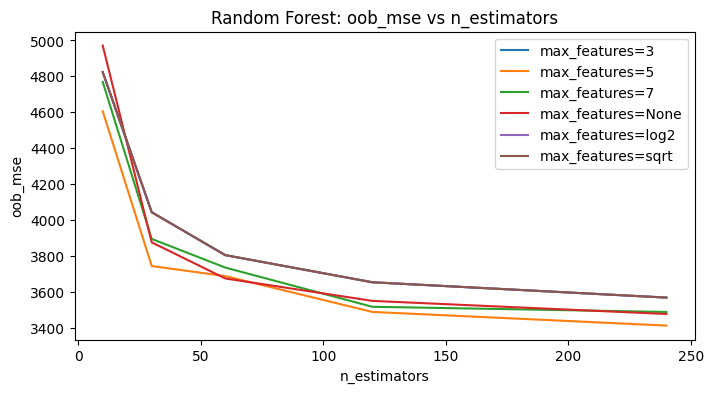

Description:
- Train MSE is usually lowest (can overfit).
- Test and OOB MSE typically decrease with more trees and then plateau.
- Smaller max_features decorrelates trees more (often better generalization), but too small can underfit.


In [16]:
def mse(a,b): 
    return mean_squared_error(a,b)

n_estimators_grid = [10, 30, 60, 120, 240]
max_features_grid = [None, "sqrt", "log2", 3, 5, 7]

records = []
for mf in max_features_grid:
    for ne in n_estimators_grid:
        rf = MyRandomForestRegressor(n_estimators=ne, max_samples=1.0, random_state=42, max_features=mf)
        rf.fit(X_train, y_train)

        # train error (using averaged prediction)
        train_pred = rf.predict(X_train)
        test_pred  = rf.predict(X_test)

        # OOB error
        oob = rf.oob_predict()
        mask = ~np.isnan(oob)
        oob_mse = mean_squared_error(y_train.iloc[mask], oob[mask])

        records.append({
            "max_features": str(mf),
            "n_estimators": ne,
            "train_mse": mse(y_train, train_pred),
            "test_mse": mse(y_test, test_pred),
            "oob_mse": oob_mse
        })

res = pd.DataFrame(records)
display(res.head())

# Plot curves for each max_features
for metric in ["train_mse", "test_mse", "oob_mse"]:
    plt.figure(figsize=(8,4))
    for mf in sorted(res["max_features"].unique()):
        sub = res[res["max_features"]==mf].sort_values("n_estimators")
        plt.plot(sub["n_estimators"], sub[metric], label=f"max_features={mf}")
    plt.xlabel("n_estimators")
    plt.ylabel(metric)
    plt.title(f"Random Forest: {metric} vs n_estimators")
    plt.legend()
    plt.show()

print(
    "Description:\n"
    "- Train MSE is usually lowest (can overfit).\n"
    "- Test and OOB MSE typically decrease with more trees and then plateau.\n"
    "- Smaller max_features decorrelates trees more (often better generalization), but too small can underfit."
)


- Visualize the difference in variance between your Decision Tree and Random Forest (which you can replicate with different parameters).

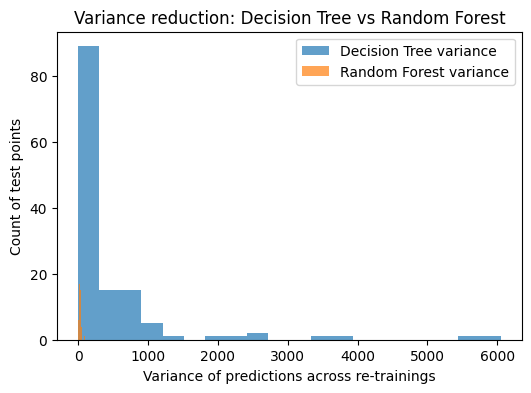

Mean variance (DT): 439.34843776106936
Mean variance (RF): 24.963361046133855
Conclusion: Random Forest shows much lower variance because averaging + feature subsampling
reduces correlation between trees and stabilizes predictions.


In [17]:
# Compare prediction variance between a single decision tree and a random forest by repeating training with different seeds.
R = 15
dt_preds_rep = []
rf_preds_rep = []

for r in range(R):
    dt = DecisionTreeRegressor(random_state=1000+r)
    dt.fit(X_train, y_train)
    dt_preds_rep.append(dt.predict(X_test))

    rf = MyRandomForestRegressor(
        n_estimators=120,
        max_samples=1.0,
        random_state=2000+r,
        max_features="sqrt"
    )
    rf.fit(X_train, y_train)
    rf_preds_rep.append(rf.predict(X_test))

dt_preds_rep = np.vstack(dt_preds_rep)
rf_preds_rep = np.vstack(rf_preds_rep)

dt_var = dt_preds_rep.var(axis=0)
rf_var = rf_preds_rep.var(axis=0)

plt.figure(figsize=(6,4))
plt.hist(dt_var, bins=20, alpha=0.7, label="Decision Tree variance")
plt.hist(rf_var, bins=20, alpha=0.7, label="Random Forest variance")
plt.xlabel("Variance of predictions across re-trainings")
plt.ylabel("Count of test points")
plt.title("Variance reduction: Decision Tree vs Random Forest")
plt.legend()
plt.show()

print("Mean variance (DT):", float(dt_var.mean()))
print("Mean variance (RF):", float(rf_var.mean()))
print(
    "Conclusion: Random Forest shows much lower variance because averaging + feature subsampling\n"
    "reduces correlation between trees and stabilizes predictions."
)


	1.	Does choosing the best feature at each step guarantee the optimal decision tree? Why/why not (chess hint)?
No. This is a greedy strategy: it picks the split that looks best right now (locally) but doesn’t evaluate how that choice will affect future splits. Like in chess, a move that improves your position immediately can still be sub-optimal if it leads to worse positions later. Therefore, greedy splitting does not guarantee a globally optimal tree.
	
	2.	Why might a Decision Tree work well on a small dataset but perform poorly on a larger one?
On small datasets, a tree can accidentally match patterns that look meaningful (and may even validate well by chance). On larger datasets, the data often contains more variability and noise, and an unconstrained tree can become very complex, overfitting many small idiosyncrasies. Without regularization (max depth, min samples per leaf, pruning), generalization can degrade.
	
	3.	How does tree depth impact overfitting and underfitting?

	•	Shallow tree (low depth): high bias → may underfit (misses important structure).
	•	Deep tree (high depth): low bias but high variance → more likely to overfit (memorizes noise).
Depth is a key knob controlling the bias–variance tradeoff.

	4.	How are categorical features handled during splitting?
A tree needs a rule to send samples left/right. Common approaches:

	•	If categories are one-hot encoded, the tree splits on each binary indicator (e.g., “is category = A?”).
	•	Some implementations support native categorical splits, grouping categories into two sets (e.g., {A,C} vs {B,D}).
In many sklearn workflows, one-hot encoding is the standard.

	5.	Why isn’t feature scaling required for Decision Trees?
Tree splits depend on ordering and thresholds of a single feature at a time (e.g., x_j \le t), not on distances or dot products. Scaling a feature usually just rescales the threshold value but doesn’t change which samples fall on each side, so performance is typically unaffected.
	6.	What happens if all observations in a node have the same target value?
The node is already pure (impurity = 0). The algorithm stops splitting and makes it a leaf that predicts that target value (or that class).
	7.	Why are Decision Trees called “white-box models”? What does that mean and why is it useful?
“White-box” means the model’s decision process is transparent and interpretable: you can trace a prediction by following the path of rules from root to leaf. This is useful when you need explainability (e.g., finance, healthcare, compliance), debugging, and building user trust.
	8.	How does class imbalance affect splits and tree performance? What can you do about it?
With imbalance, splits that improve accuracy may mainly favor the majority class, and the tree can learn rules that rarely capture the minority class (low recall). Adjustments include:

	•	Class weights (penalize minority errors more).
	•	Resampling (oversample minority, undersample majority, SMOTE).
	•	Use metrics like F1, balanced accuracy, AUC, not just accuracy.
	•	Tune/prune the tree (min samples leaf, max depth) to avoid tiny, unstable minority leaves.